# Low-Rank Optimal Transport through Factor Relaxation with Latent : A tutorial

### Introduction
This work was realised in the context of the ENSAE course "Optimal Transport: from theory to tweaks", under the supervision of M. Cuturi. This notebook aims to reproduce the algorithm introduced in <u>Low-Rank Optimal Transport through Factor Relaxation with Latent Coupling</u> (P.Halmos & al., 2024) and apply it to beginer-friendly usercases.

## Imports

Most of the code here is supported by the libraries jax.numpy and ott, which provide fast computation methods to manipulate gradients and solve optimal transport problems.

In [87]:
import jax
import jax.numpy as jnp
import ott
from ott.geometry import geometry, pointcloud
from ott.solvers import linear
import matplotlib.pyplot as plt

We generate here a random key, that we will split at convenience whenever we need to sample from any distribution.

In [88]:
key = jax.random.key(0)

## Definition of functions

The first (and arguably the most important) function that we introduce is the classic sinkhorn solver. Indeed, the algorithm presented here (henceforth FRLC) is still classified as a sinkhorn method. We will rely on the classic solver provided by the ott librairy in one of its most basic form.

In [91]:
def sinkhorn(K,a,b):
    geom = geometry.Geometry(kernel_matrix=K)
    solver = linear.sinkhorn.Sinkhorn()
    ot_problem = ott.problems.linear.linear_problem.LinearProblem(geom, a, b)
    solved = solver(ot_prob=ot_problem)
    return solved.matrix

In [89]:
def SR_proj(K, gamma, tau, a, b, delta, r, n, max_iter = 500):
    u = jnp.ones((n))
    v = jnp.ones((r))
    G = 0
    iter = 0
    while G<delta and iter<3:
        iter+=1
        u_k = u
        v_k = v
        u = a/(K@v)
        v = (b/(jnp.transpose(K)@u))**(tau/(tau +1/gamma))
        G = max(jnp.linalg.norm(jnp.log(u_k/u)), jnp.linalg.norm(jnp.log(v_k/v)))/gamma
    return jnp.diag(u)@K@jnp.diag(v)

In [92]:
def init(a, b, gQ, gR):
    keys = jax.random.split(key, 3)
    n = len(a)
    m = len(b)
    r = len(gQ)
    CQ = jax.random.uniform(keys[0], (n,r))
    CR = jax.random.uniform(keys[1], (m,r))
    CT = jax.random.uniform(keys[2], (r,r))
    KQ = jnp.exp(CQ)
    KR = jnp.exp(CR)
    KT = jnp.exp(CT)
    Q = sinkhorn(KQ, a, gQ)
    R = sinkhorn(KR, b, gR)
    T = sinkhorn(KT, jnp.transpose(Q)@jnp.ones((n)), jnp.transpose(R)@jnp.ones((m)))
    return Q, R, T

In [93]:
def Balanced_FRLC(C, r, a, b, tau, gamma, delta, eps, max_iter=100):
    n, m = jnp.shape(C)
    gQ = (1/r)*jnp.ones(r)
    gR = (1/r)*jnp.ones(r)
    Q, R, T = init(a, b, gQ, gR)
    X = jnp.diag(1/(jnp.transpose(Q)@jnp.ones((n))))@T@jnp.diag(1/(jnp.transpose(R)@jnp.ones((m))))
    Delta = float('inf')
    res = []
    iter=0
    while Delta > eps and iter<max_iter:
        iter+=1
        GradQ = C@R@jnp.transpose(X) - jnp.outer(jnp.ones((n,1)),jnp.diag(jnp.transpose(C@R@jnp.transpose(X))@Q@jnp.diag(1/gQ)))
        GradR = jnp.transpose(C)@Q@X - jnp.ones((m,1))@jnp.reshape(jnp.diag(jnp.diag(1/gR)@jnp.transpose(R)@jnp.transpose(C)@Q@X), (1,r))
        gamma_k = gamma/max(jnp.linalg.norm(GradQ, ord=1), jnp.linalg.norm(GradR, ord=1))
        KQ = Q*jnp.exp(-gamma_k*GradQ)
        KR = R*jnp.exp(-gamma_k*GradR)
        Q_new = SR_proj(KQ, gamma_k, tau, a, jnp.transpose(Q)@jnp.ones((n)), delta, r, n)
        R_new = SR_proj(KR, gamma_k, tau, b, jnp.transpose(R)@jnp.ones((m)), delta, r, m)
        gQ = jnp.transpose(Q_new)@jnp.ones((n))
        gR = jnp.transpose(R_new)@jnp.ones((m))
        GradT = jnp.diag(1/gQ)@jnp.transpose(Q_new)@C@R_new@jnp.diag(1/gR)
        gamma_t = gamma/jnp.linalg.norm(GradT, ord=1)
        KT = T*jnp.exp(-gamma_t*GradT)
        T_new = sinkhorn(KT, gQ, gR)
        X = jnp.diag(1/gQ)@T@jnp.diag(1/gR)
        Delta = (1/gamma_k**2) * (jnp.linalg.norm(Q_new - Q) + jnp.linalg.norm(R_new - R) + jnp.linalg.norm(T_new - T)) 
        Q = Q_new
        R = R_new
        T = T_new
        res.append(Q@X@jnp.transpose(R))
    return res


## Experiment

We start with one of the most basic toy exemple, by generating a dataset with points sampled from a normal distribution as a starting point, and points sampled from a uniform distribution as a target. The associated constraints are also uniformely sampled, and the cost matrix is computed with the Euclidean distance.

In [ ]:
n = 25
m = 50
r = 2

keys = jax.random.split(key, 4)
x = jax.random.normal(keys[0], (n,r)) + 1
y = jax.random.uniform(keys[1], (m,r))

a = jax.random.uniform(keys[2], (jnp.shape(x)[0]))
b = jax.random.uniform(keys[3], (jnp.shape(y)[0]))
a = a/jnp.sum(a)
b = b/jnp.sum(b)

C = pointcloud.PointCloud(x,y).cost_matrix

As we still are in two dimensions, we can plot those points onto a grid to have an idea of what we're dealing with:

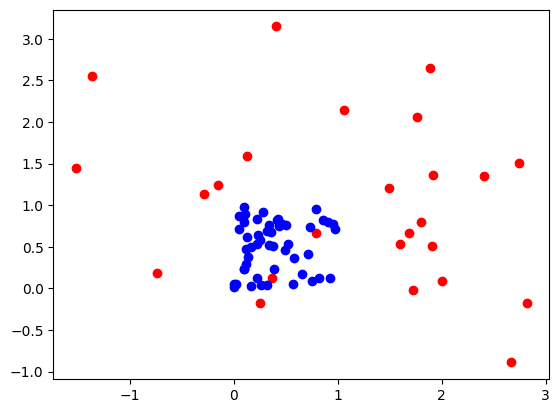

In [103]:
plt.scatter(x[:,0], x[:,1], color='red')
plt.scatter(y[:,0], y[:,1], color='blue')
plt.show()

We then introduce the parameters for the different thresholds and scales used in the algorithm. Those parameters are extremely use-case dependent, and thus have been chosen after trial and errors. One is welcome to try and play with them, as it helps to gain a better feeling of their respective effect.

In [95]:
gamma = 25
delta = 1e-4
tau = 10
eps = 1e-4

Now that we have everything that we need, it's finally time to run our algorithm!

In [84]:
P = Balanced_FRLC(C, r, a, b, tau, gamma, delta, eps)

The output keeps the transport map generated at each iteration, and thus we can look at the associated costs.

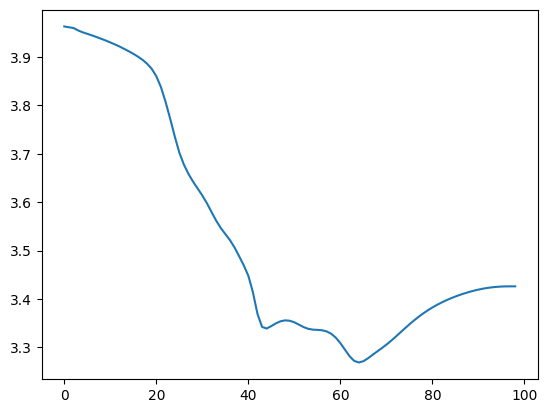

In [85]:
cost = []
for p in P:
    cost.append(jnp.sum(jnp.multiply(C,p)))
cost = cost[1:]
plt.plot(cost)
plt.show()

We still want to be sure that we are close to the constrains we defined. Our final transport map should abide by: <br>
P·<b>1</b>m = a <br>
<b>1</b>n·P = b <br>
We thus check the distance (in norm 1) between those vectors:

In [105]:
Last_P = P[-1]
print('||a - P*1(m)||_1 :' )
print(jnp.sum(jnp.abs(a - Last_P@jnp.ones(m))))

||a - P*1(m)||_1 :
0.049364418


In [106]:
print('||b - 1(n)*P||_1 :' )
print(jnp.sum(jnp.abs(b - jnp.ones(n)@Last_P)))

||b - 1(n)*P||_1 :
0.036833663
